# Einsatzdaten der Berliner Feuerwehr

## Einleitung und Fragestellung

git clone https://github.com/Berliner-Feuerwehr/BF-Open-Data

Wird die Einhaltung der Hilfsfrist bei Einsätzen der Berliner Feuerwehr stärker durch
- die Art des Einsatzes,
- die Systemlast der Leitstelle
- oder externe Faktoren wie das Wetter beeinflusst?

Abschluss:
- Kooperation mit KV Berlin
- was muss geschehen was kann besser
Hypothese: Das Wetter beeinflusst die Auslastung der Leitstellen, beides beeinflusst die Einhaltung der Hilfsfristen

Open Meteo weil REST-API + JSON, DWD hat nur CSV

Zunächst wurden die CSV dateien gesichet. Dann claude coding hinzugezogen was spannend wäre, dann analysiert

Leistellen erst ab 2024 verfügbar. Analyse dadurch eingeschränkt

### Hypothesen

1. Die Art des Einsatzes (z.B. kritischer Rettungsdienst vs. Brand) beeinflusst die Einhaltung der Hilfsfrist unterschiedlich stark — kritische Einsätze werden priorisiert und sollten häufiger eingehalten werden.
2. Eine hohe Systemlast der Leitstelle (viele unbeantwortete Anrufe, lange Antwortzeiten) korreliert mit einer schlechteren Hilfsfrist-Einhaltung.
3. Extreme Wetterlagen (Stürme, Starkregen, Hitze) erhöhen sowohl die Systemlast der Leitstelle als auch die Wahrscheinlichkeit, dass die Hilfsfrist verfehlt wird — Wetter wirkt also vermutlich indirekt über die Leitstelle.

Einschränkung: Leitstellen-/Anrufdaten sind erst ab 2024 verfügbar. Der gemeinsame Datensatz für die Modellierung ist deshalb auf 2024–2025 beschränkt, auch wenn Einsatz- und Wetterdaten weiter zurückreichen.

# Datenimport
Laden von den täglichen Missionsdaten, den täglichen Anrufdaten sowie den Einsatzdaten
Überführen in Datenformate für die spätere Analyse
Start- und Enddatum für die Analyse manuell setzen um Covid-19 Ausreißer rauszunehmen

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

#set start and end date for analysis
start_date = pd.Timestamp("2022-01-01")
end_date = pd.Timestamp("2025-12-31")

#daily mission data
df_daily_mission = pd.read_csv("data/BF-Open-Data/Datasets/Daily_Data/BFw_mission_data_daily.csv")
#daily mission set in date format
df_daily_mission["mission_created_date"] = pd.to_datetime (df_daily_mission["mission_created_date"])
df_daily_mission = df_daily_mission.set_index("mission_created_date").sort_index()


#daily call data
df_daily_call = pd.read_csv("data/BF-Open-Data/Datasets/Daily_Data/BFw_call_data_daily.csv")
#daily call set to date format
df_daily_call["calls_received_day"] = pd.to_datetime(df_daily_call["calls_received_day"])
df_daily_call = df_daily_call.sort_values("calls_received_day").set_index("calls_received_day")
#call_count als str eingelesen → in int umwandeln
df_daily_call["call_count"] = pd.to_numeric(df_daily_call["call_count"], errors="coerce")

#mission data set
df_mission_data = pd.concat([
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2022.csv", low_memory=False),
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2023.csv", low_memory=False),
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2024.csv", low_memory=False),
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2025.csv", low_memory=False),], ignore_index=True)

#mission data set to date format
df_mission_data["mission_date"] = pd.to_datetime(df_mission_data["mission_date"])
df_mission_data = df_mission_data.set_index("mission_date").sort_index()

#Filter for datas
df_daily_mission = df_daily_mission.loc[start_date:end_date]
df_daily_call = df_daily_call.loc[start_date:end_date]
df_mission_data = df_mission_data.loc[start_date:end_date]

In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"start_date": "2022-01-01",
	"end_date": "2025-12-31",
	"daily": ["temperature_2m_max", "weather_code", "precipitation_sum", "snowfall_sum", "wind_speed_10m_max"],
	"timezone": "Europe/Berlin",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_weather_code = daily.Variables(1).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(3).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(4).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["weather_code"] = daily_weather_code
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max

df_weather = pd.DataFrame(data = daily_data)
df_weather = df_weather.set_index("date")
df_weather.index = df_weather.index.tz_localize(None)
print("\nDaily data\n", df_weather)



Coordinates: 52.52000045776367°N 13.419998168945312°E
Elevation: 38.0 m asl
Timezone: b'Europe/Berlin'b'GMT+2'
Timezone difference to GMT+0: 7200s

Daily data
                      temperature_2m_max  weather_code  precipitation_sum  \
date                                                                       
2021-12-31 23:00:00             12.0500          51.0                0.6   
2022-01-01 23:00:00             11.6500          53.0                2.3   
2022-01-02 23:00:00             10.0500          55.0                2.9   
2022-01-03 23:00:00              7.2000          51.0                2.3   
2022-01-04 23:00:00              4.6000          51.0                0.7   
...                                 ...           ...                ...   
2025-12-26 23:00:00              3.6455          77.0                0.1   
2025-12-27 23:00:00              2.7455           3.0                0.0   
2025-12-28 23:00:00              4.4955          77.0                0.5   
2025

# Datenverständnis

Überblick über die Daten verschaffen, um herauszufinden wie viele Daten vorhanden sind

In [3]:
# mission data
print(df_mission_data.shape)
print(df_daily_mission.dtypes)
df_mission_data.head()

#missing values
df_mission_data.isnull().sum()

#zielvariable prüfen
print(df_mission_data["response_time"].describe())
print((df_mission_data["response_time"] <= 480).mean())

(2129064, 16)
mission_count_all                                   int64
mission_count_ems                                   int64
mission_count_ems_critical                          int64
mission_count_ems_critical_cpr                      int64
mission_count_fire                                  int64
mission_count_technical_rescue                      int64
mission_count_rd1                                   int64
mission_count_rd2                                   int64
mission_count_rd3                                   int64
mission_count_rd4                                   int64
mission_count_rd5                                   int64
response_time_ems_critical_mean                   float64
response_time_ems_critical_median                 float64
response_time_ems_critical_std                    float64
response_time_ems_critical_cpr_mean               float64
response_time_ems_critical_cpr_median             float64
response_time_ems_critical_cpr_std                float64


Über 2 Millionen Einsätze, 16 Variabeln

Hilsfrist beträgt in Deutschland 8 Minuten (480 Sekunden):
Mean: 677 Sekunden (ca 11 Minuten)
Median: 625 Sekunden (ca 10 Minuten)
Min: 121 Sekunden
Max: 1919 Sekunden (ca 32 Minuten)
Count: ca 264.000 Einträge haben keinen Wert (NaN) --> ca 12% muss bereinigt werden
17,2% der Einsätze halten die Hilfsfrist ein


In [4]:
#daily mission data
print(df_daily_mission.shape)
print(df_daily_mission.dtypes)
df_daily_mission.head()

#missing values
df_daily_mission.isnull().sum()

#zielvariable prüfen
print(df_daily_mission["response_time_ems_critical_mean"].describe())
print(df_daily_mission["response_time_ems_critical_cpr_mean"].describe())

(1461, 29)
mission_count_all                                   int64
mission_count_ems                                   int64
mission_count_ems_critical                          int64
mission_count_ems_critical_cpr                      int64
mission_count_fire                                  int64
mission_count_technical_rescue                      int64
mission_count_rd1                                   int64
mission_count_rd2                                   int64
mission_count_rd3                                   int64
mission_count_rd4                                   int64
mission_count_rd5                                   int64
response_time_ems_critical_mean                   float64
response_time_ems_critical_median                 float64
response_time_ems_critical_std                    float64
response_time_ems_critical_cpr_mean               float64
response_time_ems_critical_cpr_median             float64
response_time_ems_critical_cpr_std                float64
res

Critical EMS:
- Mean: 642 Sekunden (ca. 10.7 Minuten)
- Min: 558 Sekunden (ca. 9.3 Minuten) !!!

Critical EMS CPR:
- Mean: 505 Sekunden (ca. 8.4 Minuten)
- Min: 360 Sekunden (6 Minuten)

CPR Einsätze werden schneller beantwortet als allgemein kritische Fälle. Annahme: Priorisierungssystem der Leistelle funktioniert. CPR hat höchste prio.

In [5]:
#daily calls
print(df_daily_call.shape)
print(df_daily_call.dtypes)
df_daily_call.head()

#missing values
df_daily_call.isnull().sum()

#zielvariable prüfen
print(df_daily_call["answer_time_mean_112"].describe())
print(df_daily_call["call_count_112"].describe())
print(df_daily_call["call_count_112_not_answered"].describe())
print(df_daily_call["call_count_112_answered_after_60_seconds"].describe())
print(df_daily_call["call_count_112_answered_within_10_seconds"].describe())

#Für die Systemauslastung
#Anteil nicht beantworteter Anrufe
#call_count_112 zählt laut Datenbeschreibung nur beantwortete Anrufe → korrekter Nenner: call_count_112 + call_count_112_not_answered
print("not answered rate")
df_daily_call["not_answered_rate"] = df_daily_call["call_count_112_not_answered"] / (df_daily_call["call_count_112"] + df_daily_call["call_count_112_not_answered"])
print(df_daily_call["not_answered_rate"].describe())

#Anteil nach 60 Sekunden beantwortet
print("after 60 rate")
df_daily_call["after_60s_rate"] = df_daily_call["call_count_112_answered_after_60_seconds"] / df_daily_call["call_count_112"]
print(df_daily_call["after_60s_rate"].describe())

(731, 12)
call_count                                   float64
answer_time_mean                             float64
answer_time_median                           float64
answer_time_std                              float64
call_count_not_answered                        int64
call_count_112                                 int64
answer_time_mean_112                         float64
answer_time_median_112                       float64
answer_time_std_112                          float64
call_count_112_not_answered                    int64
call_count_112_answered_within_10_seconds      int64
call_count_112_answered_after_60_seconds       int64
dtype: object
count    731.000000
mean      26.121094
std       10.197669
min        9.160000
25%       18.245000
50%       24.410000
75%       31.940000
max       68.590000
Name: answer_time_mean_112, dtype: float64
count     731.000000
mean     2315.545828
std       215.568643
min      1366.000000
25%      2181.500000
50%      2288.000000
75%      24

In [6]:
from scipy import stats

#Ausreißer mit Z score herausfinden (claude gefragt)
z_score = stats.zscore(df_daily_call["not_answered_rate"])
ausreisser = df_daily_call[abs(z_score) > 3]
print(ausreisser.sort_values("not_answered_rate", ascending = False))

                    call_count  answer_time_mean  answer_time_median  \
calls_received_day                                                     
2025-01-01              3226.0             39.46                9.81   
2025-06-23              3741.0             49.65               15.44   
2025-06-26              2757.0             40.66                7.52   

                    answer_time_std  call_count_not_answered  call_count_112  \
calls_received_day                                                             
2025-01-01                    72.43                     3709            3015   
2025-06-23                    82.28                     2954            3464   
2025-06-26                   100.85                     2000            2551   

                    answer_time_mean_112  answer_time_median_112  \
calls_received_day                                                 
2025-01-01                         40.67                   10.04   
2025-06-23                        

Die Z-Score-Ausreißer (`|z|>3`) bei `not_answered_rate` und `after_60s_rate` lassen sich größtenteils erklären:

- **01.01.2025**: laut README-Disclaimer der Berliner Feuerwehr gab es zum Jahreswechsel 24/25 eine technische Einschränkung der 112-Rufnummer, Notrufe liefen über ein Fallback-System ohne automatisierte Erfassung. Die Zahlen für diesen Tag sind unvollständig → **wird aus der Analyse entfernt**, da es sich um einen Datenfehler statt um eine echte Lastspitze handelt.
- **23.06. und 26.06.2025**: an beiden Tagen gab es laut Open-Meteo-Daten schwere Gewitter mit Windböen von 85–88 km/h (weather_code 95/96) nach einer Hitzewelle. Das erklärt den Anstieg unbeantworteter Notrufe plausibel und **belegbar** → bleibt in den Daten, dient sogar als Beispiel für den vermuteten Wetter→Leitstelle-Zusammenhang.
- **07.09. und 20.11.2024**: keine Wetterauffälligkeiten an diesen Tagen. Mögliche Erklärung: Großveranstaltungen (07.09. Start von Lollapalooza Berlin, 20.11. diverse Konzerte) könnten zu mehr Notrufen geführt haben — diese Erklärung ist aber **nicht belegt**, da in einer Stadt mit 3,8 Mio. Einwohnern an fast jedem Tag irgendwelche Veranstaltungen stattfinden. Die Tage bleiben in den Daten, werden aber als ungeklärt dokumentiert statt kausal erklärt.

FEHLER MEINERSEITS (aus dem vorherigen Durchgang): die `call_count`-Spalten zählen nur die *beantworteten* Anrufe, nicht alle eingegangenen — das hat die ursprüngliche Berechnung der Rate verzerrt, ist hier aber bereits korrigiert (Nenner = `call_count_112 + call_count_112_not_answered`).

Antwortzeit wird von der Björn Steigerstiftung für kritische fälle
answer_time_mean_112:
- Mean: 26 Sekunden
- Max: 68 Sekunden

not_answered_rate:
mean 34,6%
Max 121% (?)

after_60s_rate:
- mean 13,2%
- max 40,4%


In [7]:
#Wetterdaten
print(df_weather.shape)
print(df_weather.dtypes)
df_weather.head()

#missing values
print(df_weather.isnull().sum())

#zielvariable prüfen
print(df_weather.describe())

(1461, 5)
temperature_2m_max    float32
weather_code          float32
precipitation_sum     float32
snowfall_sum          float32
wind_speed_10m_max    float32
dtype: object
temperature_2m_max    0
weather_code          0
precipitation_sum     0
snowfall_sum          0
wind_speed_10m_max    0
dtype: int64
       temperature_2m_max  weather_code  precipitation_sum  snowfall_sum  \
count         1461.000000   1461.000000        1461.000000   1461.000000   
mean            15.343751     41.247089           1.569404      0.034209   
std              8.650467     34.070755           3.347269      0.268591   
min             -4.954500      0.000000           0.000000      0.000000   
25%              8.345500      3.000000           0.000000      0.000000   
50%             15.345500     51.000000           0.100000      0.000000   
75%             22.345499     77.000000           1.500000      0.000000   
max             37.650002     99.000000          40.099995      6.369999   

       w

# Datenbereinigung

**Zeitraum:** Mission- und Wetterdaten reichen weiter zurück (2018 bzw. 2022), aber `df_daily_call` existiert erst seit 2024. Da die Leitstellen-Auslastung zentral für unsere Fragestellung ist, beschränken wir den gemeinsamen Datensatz für die Modellierung auf **2024–2025**. Explorative Auswertungen, die nur Mission- oder Wetterdaten brauchen, können trotzdem den längeren Zeitraum nutzen.

**Wetterdaten-Bug:** Durch die UTC→Europe/Berlin-Konvertierung landet der Zeitindex von `df_weather` auf 23:00 Uhr des Vortags statt auf Mitternacht (z.B. `2021-12-31 23:00:00` statt `2022-01-01`). Vor dem Join wird der Index korrigiert (+1 Stunde, dann auf den Tag normalisiert), sonst würden Wetterdaten dem falschen Tag zugeordnet.

**response_time NaN:** ca. 12% der Einsätze (≈265.000 von 1,86 Mio.) haben keinen Wert bei `response_time` — vermutlich weil nicht alle relevanten Zeitstempel vorlagen (siehe Felddokumentation: `..._timegoal_computed`). Diese Zeilen werden entfernt, da sich für sie keine Zielvariable berechnen lässt.

**response_time Ausreißer werden NICHT entfernt:** Ein Z-Score-Test zeigt ca. 36.000 Einsätze (~2%) mit ungewöhnlich langer Reaktionszeit (1455–1919 Sekunden). Das sind keine Messfehler (keine negativen/unplausiblen Werte), sondern genau die Fälle, in denen die Hilfsfrist verfehlt wurde — also der Kern unserer Fragestellung. Sie zu entfernen würde die Zielvariable künstlich verzerren.

**dispatchcode_criticality / dispatchcode_category NaN:** ca. 111.000 Einsätze haben keinen Dispatchcode (vermutlich Einsatztypen wie "Sonstige" oder "Notverlegung", die nicht über das normale Disponierungsschema laufen). Statt diese Zeilen zu droppen (zu hoher Datenverlust), wird eine eigene Kategorie "unbekannt" eingeführt.

**Zielvariable:** `hilfsfrist = response_time <= 480` (480 Sekunden = gesetzliche 8-Minuten-Frist in Deutschland).

**Zeitliche Features:** aus `mission_date` werden Wochentag und Monat extrahiert. Eine Uhrzeit-Variable ("Stunde") ist nicht möglich, da `mission_date` in allen Jahresdateien (2018–2026) ausschließlich das Datum ohne Uhrzeitkomponente enthält — keiner der verfügbaren BF-Open-Data-Datensätze (Mission_Data, Daily_Data, Turnout_Times, KV_Data, Regional_Data) liefert eine Uhrzeit-Auflösung.


In [8]:
#Wetter anpassen, Zeitstempel-Bug korrigieren
df_weather.index = (df_weather.index + pd.Timedelta(hours=1)).normalize()

#Kontrolle
print(df_weather.index.min(), df_weather.index.max())
print(df_weather.head())
print(df_weather.tail())

2022-01-01 00:00:00 2025-12-31 00:00:00
            temperature_2m_max  weather_code  precipitation_sum  snowfall_sum  \
date                                                                            
2022-01-01               12.05          51.0                0.6           0.0   
2022-01-02               11.65          53.0                2.3           0.0   
2022-01-03               10.05          55.0                2.9           0.0   
2022-01-04                7.20          51.0                2.3           0.0   
2022-01-05                4.60          51.0                0.7           0.0   

            wind_speed_10m_max  
date                            
2022-01-01           23.444265  
2022-01-02           29.168886  
2022-01-03           36.447220  
2022-01-04           16.243940  
2022-01-05           29.478260  
            temperature_2m_max  weather_code  precipitation_sum  snowfall_sum  \
date                                                                            

In [9]:
# response_time NaN entfernen
print("vorher:", df_mission_data.shape)
#dropna löscht Zeilen wo NaN ist
df_mission_data = df_mission_data.dropna(subset=["response_time"])
print("nachher", df_mission_data.shape)

vorher: (2129064, 16)
nachher (1864875, 16)


In [10]:
# Zielvariable Hilfsfrist eingehalten
df_mission_data["hilfsfrist"] = df_mission_data["response_time"] <= 480
print(df_mission_data["hilfsfrist"].value_counts(normalize=True))

# Wochentag und Monat aus dem Datums-Index rausziehen
df_mission_data["wochentag"] = df_mission_data.index.day_name()
df_mission_data["monat"] = df_mission_data.index.month

print(df_mission_data[["wochentag", "monat"]].head())

hilfsfrist
False    0.80334
True     0.19666
Name: proportion, dtype: float64
             wochentag  monat
mission_date                 
2022-01-01    Saturday      1
2022-01-01    Saturday      1
2022-01-01    Saturday      1
2022-01-01    Saturday      1
2022-01-01    Saturday      1


### Kategoriale Variablen encodieren

Modelle rechnen nur mit Zahlen, nicht mit Text wie `"Brand"` oder `"Mitte"`.

- **NaN bei `dispatchcode_criticality`** → wird zu eigener Kategorie `"unbekannt"` (statt Zeilen zu löschen).
- **One-Hot-Encoding** für `mission_type`, `mission_location_district`, `dispatchcode_criticality`: jede Kategorie wird eine eigene 0/1-Spalte. So entsteht keine künstliche Rangordnung zwischen den Kategorien (z.B. Bezirken), wie es bei einer einfachen Durchnummerierung der Fall wäre.
- Ergebnis: mehr Spalten, gleich viele Zeilen.

In [11]:
# NaN bei Dispatchcode als eigene Kategorie "unbekannt"
df_mission_data["dispatchcode_criticality"] = df_mission_data["dispatchcode_criticality"].fillna("unbekannt")

# One-Hot-Encoding der nominal kategorialen Variabeln
df_mission_data = pd.get_dummies(
    df_mission_data,
    columns=["mission_type", "mission_location_district", "dispatchcode_criticality"],
    prefix=["typ", "district", "criticality"],
)

print(df_mission_data.shape)
df_mission_data.head()

# Nach Rettungsdienst-Einsätze filtern für Hilfsfrist (inkl. Mischtyp mit Technischer Hilfeleistung, da beide AMPDS-Dispatchcodes haben)
print("vorher: ", df_mission_data.shape)
df_mission_data = df_mission_data[
    (df_mission_data["typ_Rettungsdienst"] == True) |
    (df_mission_data["typ_Rettungsdienst mit Technischer Hilfeleistung"] == True)
]
print("nachher:", df_mission_data.shape)

(1864875, 41)
vorher:  (1864875, 41)
nachher: (1714419, 41)


In [12]:
# Silvester-Tag entfernen: dokumentierter Systemausfall (README-Disclaimer), keine echte Lastspitze
print("vorher:", df_daily_call.shape)
df_daily_call = df_daily_call.drop(pd.Timestamp("2025-01-01"))
print("nachher:", df_daily_call.shape)

vorher: (731, 14)
nachher: (730, 14)


# Explorative Analyse: Vorgehen

Wir schauen uns die Daten in vier Stufen an, statt direkt mit komplexen Visualisierungen zu starten:

1. **Langer Zeitraum (2022–2025), einzeln:** Einsatztyp, Wetter, Wochentag, Monat — je für sich gegen `hilfsfrist`. Zeigt schnell, welche Variablen überhaupt einen Effekt haben.
2. **Langer Zeitraum, kombiniert:** z.B. Heatmap Wochentag × Monat — nur für Variablen, die in Stufe 1 einzeln schon ein Muster zeigen.
3. **Kurzer Zeitraum (2024–2025), einzeln:** Leitstellen-Variablen (`not_answered_rate`, `answer_time_mean_112`, ...) gegen `hilfsfrist`/`response_time`. Geht nicht über den langen Zeitraum, da Leitstellendaten erst ab 2024 existieren.
4. **Kurzer Zeitraum, kombiniert:** Leitstelle zusammen mit Wetter bzw. Einsatztyp — testet direkt Hypothese 3 (wirkt Wetter indirekt über die Leitstelle auf die Hilfsfrist?).

O            0.096576
A            0.151716
B            0.176774
C            0.184365
D            0.264220
E            0.448182
unbekannt    0.336278
dtype: float64


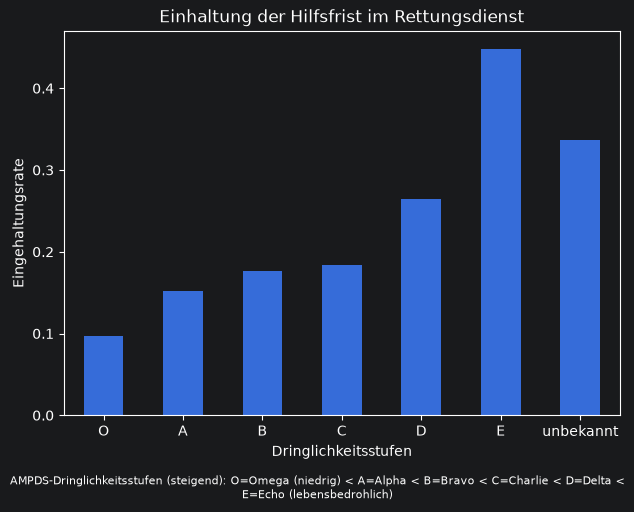

In [15]:
# Hilfsfrist-Quote pro Kritikalitätsstufe (statt Einsatztyp, da jetzt nur noch Rettungsdienst)
crit_spalten = [col for col in df_mission_data.columns if col.startswith("criticality_")]
quote_je_crit = {
    col.replace("criticality_", ""): df_mission_data.loc[df_mission_data[col], "hilfsfrist"].mean()
    for col in crit_spalten
}
quote_je_crit = pd.Series(quote_je_crit)

# Nach AMPDS-Dringlichkeit sortieren (O < A < B < C < D < E), statt nach Quote
reihenfolge = ["O", "A", "B", "C", "D", "E", "unbekannt"]
quote_je_crit = quote_je_crit.reindex([k for k in reihenfolge if k in quote_je_crit.index])

print(quote_je_crit)

quote_je_crit.plot(kind="bar")
plt.ylabel("Eingehaltungsrate")
plt.xlabel("Dringlichkeitsstufen")
plt.title("Einhaltung der Hilfsfrist im Rettungsdienst")
plt.xticks(rotation=0)

# Legende/Erklärung der AMPDS-Stufen als Bildunterschrift
plt.figtext(
    0.5, -0.05,
    "AMPDS-Dringlichkeitsstufen (steigend): O=Omega (niedrig) < A=Alpha < B=Bravo < C=Charlie < D=Delta < E=Echo (lebensbedrohlich)",
    wrap=True, ha="center", fontsize=8
)

plt.tight_layout()
plt.show()

# Quellen

https://rettungslandschaft.steiger-stiftung.de/notrufbearbeitung-und-hilfsfrist/
https://www.elab2go.de/demo-py/
https://open-meteo.com/en/docs/historical-forecast-api?start_date=2022-01-01&end_date=2025-12-31&timezone=Europe%2FBerlin&hourly=&daily=temperature_2m_max,weather_code,precipitation_sum,snowfall_sum,wind_speed_10m_max#hourly_weather_variables